# NIFTY 50 Financial Data Analysis

## Week 4 — Hypothesis Testing

**Student Name:** Pavan Poriya  
**Project:** NIFTY 50 Financial Data Analysis  
**Analysis Period:** 17 September 2007 – 20 February 2026  
**Dataset Source:** NIFTY 50 Historical Data (Kaggle)

---


## 1. Week 4 Objective

The primary objective of Week 4 is to conduct a statistically rigorous hypothesis test on the historical daily returns of the NIFTY 50 index. 

Building upon the Exploratory Data Analysis (Week 1), Financial Forecasting (Week 2), and Risk Analysis (Week 3), this module establishes formal statistical inference regarding the long-term expected daily return of the Indian benchmark index.

**Key Steps Included:**
1. Hypothesis formulation grounded in financial economic theory.
2. Comprehensive statistical assumption testing and distribution evaluation.
3. Parametric (One-Sample t-test) and Non-Parametric (Wilcoxon Signed-Rank test) statistical testing.
4. Calculation of exact test statistics, p-values, and 95% confidence intervals.
5. Interpretation of results with explicit distinction between statistical and economic significance.
6. Publication-quality visual presentation.


## 2. Research Question

In financial risk management and portfolio theory, understanding whether daily market index returns have a positive expected value is fundamental to evaluating long-term buy-and-hold equity risk premia versus zero-mean random walk assumptions.

**Core Research Question:**
> *"Is the average daily return of the NIFTY 50 index significantly different from zero over the analyzed period (2007–2026)?"*


## 3. Hypothesis Formulation

To test the research question, we establish a two-sided one-sample hypothesis test comparing the population mean daily return ($\mu$) against zero (0.00%).

* **Null Hypothesis ($H_0$):** The population mean daily return of the NIFTY 50 index is equal to zero.
  $$H_0: \mu = 0$$

* **Alternative Hypothesis ($H_1$):** The population mean daily return of the NIFTY 50 index is not equal to zero.
  $$H_1: \mu \neq 0$$

* **Significance Level ($\alpha$):
  $$\alpha = 0.05$$
  *(95% Confidence Level)*


## 4. Dataset Loading

We import the necessary scientific computing libraries (`pandas`, `numpy`, `scipy.stats`, `matplotlib`, `seaborn`) and load the historical dataset.


In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import IPython.display as display
import warnings
warnings.filterwarnings('ignore')

# Load raw dataset
df_raw = pd.read_csv('DataSet/NIFTY50_1995_to_Feb_2026.csv')
print(f"Raw Dataset Shape: {df_raw.shape}")
print("Raw Dataset Columns:", df_raw.columns.tolist())
df_raw.head(3)


Raw Dataset Shape: (4523, 10)
Raw Dataset Columns: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Ticker', 'Daily_Return_%', 'MA_50', 'MA_200']


,Date,Close,High,Low,Open,Volume,Ticker,Daily_Return_%,MA_50,MA_200
0,NaN,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI,NaN,NaN,NaN,NaN
1,2007-09-17,4494.64990234375,4549.0498046875,4482.85009765625,4518.4501953125,0,^NSEI,NaN,NaN,NaN
2,2007-09-18,4546.2001953125,4551.7998046875,4481.5498046875,4494.10009765625,0,^NSEI,1.146926,NaN,NaN


## 5. Data Preparation

We clean the dataset by removing the metadata row at index 0, casting `Date` to standard datetime format, converting numeric columns, and isolating valid `Daily_Return_%` values.


In [2]:
# Replicate standard project cleaning
df = df_raw.iloc[1:].copy()
df['Date'] = pd.to_datetime(df['Date'])
df['Daily_Return_%'] = pd.to_numeric(df['Daily_Return_%'])
df = df.sort_values('Date').reset_index(drop=True)

# Data summary for hypothesis test
total_obs = len(df)
missing_returns = df['Daily_Return_%'].isna().sum()

# Extract valid return series
clean_returns = df['Daily_Return_%'].dropna()
valid_obs = len(clean_returns)

print(f"Total Cleaned Dataset Rows: {total_obs}")
print(f"Missing Daily Return Rows: {missing_returns}")
print(f"Valid Daily Return Observations Used in Test (n): {valid_obs}")
print(f"Date Range Analyzed: {df['Date'].min().strftime('%Y-%m-%d')} to {df['Date'].max().strftime('%Y-%m-%d')}")


Total Cleaned Dataset Rows: 4522
Missing Daily Return Rows: 1
Valid Daily Return Observations Used in Test (n): 4521
Date Range Analyzed: 2007-09-17 to 2026-02-20


## 6. Descriptive Statistics

Before performing inferential testing, we calculate baseline descriptive statistics for daily returns.


In [3]:
# Descriptive statistics calculation
stats_dict = {
    'Metric': [
        'Total Cleaned Rows',
        'Valid Return Observations (n)',
        'Mean Daily Return (%)',
        'Median Daily Return (%)',
        'Standard Deviation (%)',
        'Minimum Daily Return (%)',
        '25th Percentile (Q1) (%)',
        '75th Percentile (Q3) (%)',
        'Maximum Daily Return (%)',
        'Skewness',
        'Excess Kurtosis'
    ],
    'Value': [
        f"{total_obs:,}",
        f"{valid_obs:,}",
        f"{clean_returns.mean():.6f}%",
        f"{clean_returns.median():.6f}%",
        f"{clean_returns.std(ddof=1):.6f}%",
        f"{clean_returns.min():.6f}%",
        f"{clean_returns.quantile(0.25):.6f}%",
        f"{clean_returns.quantile(0.75):.6f}%",
        f"{clean_returns.max():.6f}%",
        f"{clean_returns.skew():.6f}",
        f"{clean_returns.kurtosis():.6f}"
    ]
}

desc_df = pd.DataFrame(stats_dict)
display.display(desc_df)


,Metric,Value
0,Total Cleaned Rows,"4,522"
1,Valid Return Observations (n),"4,521"
2,Mean Daily Return (%),0.046935%
3,Median Daily Return (%),0.062461%
4,Standard Deviation (%),1.301451%
5,Minimum Daily Return (%),-12.980466%
6,25th Percentile (Q1) (%),-0.521096%
7,75th Percentile (Q3) (%),0.652062%
8,Maximum Daily Return (%),17.744066%
9,Skewness,0.056058


## 7. Test Selection and Assumptions

### Statistical Test Selection
We select the **Two-Sided One-Sample t-Test** as the primary inferential test to evaluate whether the sample mean return differs significantly from zero.

### Assumptions & Validity Discussion
1. **Sample Size ($n = 4521$):** Large sample size significantly exceeds standard threshold ($n \ge 30$).
2. **Independence:** Daily financial returns display slight autocorrelation during shock periods, but are treated as independently distributed observations under standard financial asset pricing assumptions.
3. **Distribution & Normality:** Financial daily returns exhibit heavy tails (fat tails) and excess kurtosis (16.07). However, under the **Central Limit Theorem (CLT)**, for a sample size of $n = 4521$, the sampling distribution of the mean is approximately normal regardless of population non-normality.
4. **Robustness Check:** To ensure results are not driven by extreme outliers or non-normality, we also conduct the non-parametric **Wilcoxon Signed-Rank Test** as a secondary validation.


In [4]:
# Jarque-Bera Normality Test
jb_stat, jb_p_val = stats.jarque_bera(clean_returns)
print("=== Distribution Normality Evaluation ===")
print(f"Skewness: {clean_returns.skew():.4f}")
print(f"Excess Kurtosis: {clean_returns.kurtosis():.4f}")
print(f"Jarque-Bera Statistic: {jb_stat:,.2f}")
print(f"Jarque-Bera p-value: {jb_p_val:.6e}")
print("Conclusion: Returns exhibit significant non-normality (fat tails), justifying CLT reliance and non-parametric robustness checks.")


=== Distribution Normality Evaluation ===
Skewness: 0.0561
Excess Kurtosis: 16.0672
Jarque-Bera Statistic: 48,516.68
Jarque-Bera p-value: 0.000000e+00
Conclusion: Returns exhibit significant non-normality (fat tails), justifying CLT reliance and non-parametric robustness checks.


## 8. Primary Statistical Test & Robustness Test

We perform the calculation using `scipy.stats.ttest_1samp` (Primary t-test) and `scipy.stats.wilcoxon` (Secondary non-parametric test).


In [5]:
# Primary Test: One-Sample t-test
t_stat, p_val_t = stats.ttest_1samp(clean_returns, 0.0)

# Degrees of Freedom
df_val = valid_obs - 1

# Standard Error & 95% Confidence Interval
mean_val = clean_returns.mean()
std_val = clean_returns.std(ddof=1)
se_val = std_val / np.sqrt(valid_obs)
ci_lower, ci_upper = stats.t.interval(0.95, df=df_val, loc=mean_val, scale=se_val)

# Secondary Robustness Test: Wilcoxon Signed-Rank Test
w_stat, p_val_w = stats.wilcoxon(clean_returns)

print("=== PRIMARY TEST: ONE-SAMPLE T-TEST ===")
print(f"Sample Mean (μ_hat): {mean_val:.6f}%")
print(f"Standard Error (SE): {se_val:.6f}%")
print(f"Degrees of Freedom: {df_val}")
print(f"t-Statistic: {t_stat:.6f}")
print(f"p-Value (two-sided): {p_val_t:.6e} ({p_val_t:.6f})")
print(f"95% Confidence Interval for Mean: [{ci_lower:.6f}%, {ci_upper:.6f}%")

print()
print("=== SECONDARY TEST: WILCOXON SIGNED-RANK TEST ===")
print(f"Wilcoxon Statistic: {w_stat:,.1f}")
print(f"p-Value (Wilcoxon): {p_val_w:.6e} ({p_val_w:.6f})")


=== PRIMARY TEST: ONE-SAMPLE T-TEST ===
Sample Mean (μ_hat): 0.046935%
Standard Error (SE): 0.019356%
Degrees of Freedom: 4520
t-Statistic: 2.424855
p-Value (two-sided): 1.535346e-02 (0.015353)
95% Confidence Interval for Mean: [0.008988%, 0.084882%

=== SECONDARY TEST: WILCOXON SIGNED-RANK TEST ===
Wilcoxon Statistic: 4,748,216.0
p-Value (Wilcoxon): 5.443294e-05 (0.000054)


## 9. Test Results Summary Table

We consolidate all calculated statistical metrics into a formatted summary table.


In [6]:
results_table = pd.DataFrame({
    'Test Name': ['One-Sample t-Test (Primary)', 'Wilcoxon Signed-Rank Test (Robustness)'],
    'Null Hypothesis (H0)': ['μ = 0.00%', 'Median = 0.00%'],
    'Test Statistic': [f"t = {t_stat:.4f}", f"W = {w_stat:,.1f}"],
    'p-Value': [f"{p_val_t:.6f} (p < 0.05)", f"{p_val_w:.6f} (p < 0.05)"],
    'Significance Level (α)': ['0.05', '0.05'],
    'Statistical Decision': ['Reject H0', 'Reject H0']
})

display.display(results_table)


,Test Name,Null Hypothesis (H0),Test Statistic,p-Value,Significance Level (α),Statistical Decision
0,One-Sample t-Test (Primary),μ = 0.00%,t = 2.4249,0.015353 (p < 0.05),0.05,Reject H0
1,Wilcoxon Signed-Rank Test (Robustness),Median = 0.00%,"W = 4,748,216.0",0.000054 (p < 0.05),0.05,Reject H0


## 10. Decision Rule & Evaluation

### Formal Decision Rule:
* **If p-value $< \alpha$ (0.05):** Reject the null hypothesis ($H_0$). There is statistically significant evidence that the mean daily return is non-zero.
* **If p-value $\ge \alpha$ (0.05):** Fail to reject the null hypothesis ($H_0$). There is insufficient evidence to claim the mean daily return differs from zero.

*(Note: In accordance with standard statistical methodology, we state "Fail to reject H0" rather than "Accept H0".)*


In [7]:
alpha = 0.05

print("=== STATISTICAL DECISION EVALUATION ===")
if p_val_t < alpha:
    print(f"Result: p-value ({p_val_t:.6f}) < alpha ({alpha})")
    print("DECISION: REJECT THE NULL HYPOTHESIS (H0).")
    print("CONCLUSION: The mean daily return of the NIFTY 50 is statistically significantly different from zero at the 5% significance level.")
else:
    print(f"Result: p-value ({p_val_t:.6f}) >= alpha ({alpha})")
    print("DECISION: FAIL TO REJECT THE NULL HYPOTHESIS (H0).")
    print("CONCLUSION: There is insufficient evidence to conclude that the mean daily return differs from zero.")


=== STATISTICAL DECISION EVALUATION ===
Result: p-value (0.015353) < alpha (0.05)
DECISION: REJECT THE NULL HYPOTHESIS (H0).
CONCLUSION: The mean daily return of the NIFTY 50 is statistically significantly different from zero at the 5% significance level.


## 11. Statistical Interpretation

### Key Findings:
1. **p-Value Interpretation:** The p-value of **0.015353** represents the probability of observing a sample mean daily return as extreme as **+0.046935%** (or more extreme) purely by random chance if the true population mean return were exactly zero.
2. **Statistical Evidence:** Because $p = 0.015353 < 0.05$, we have sufficient empirical evidence to reject the null hypothesis $H_0$.
3. **95% Confidence Interval:** We are 95% confident that the true population mean daily return of the NIFTY 50 index lies between **+0.008988%** and **+0.084882%** per trading session.
4. **Non-Parametric Verification:** The Wilcoxon test p-value ($0.000054 < 0.05$) confirms that the distribution center is significantly shifted above zero, proving the result is robust against heavy tails and outliers.


## 12. Visualization

We plot the historical return distribution alongside the sample mean, null hypothesis baseline, and 95% confidence interval.


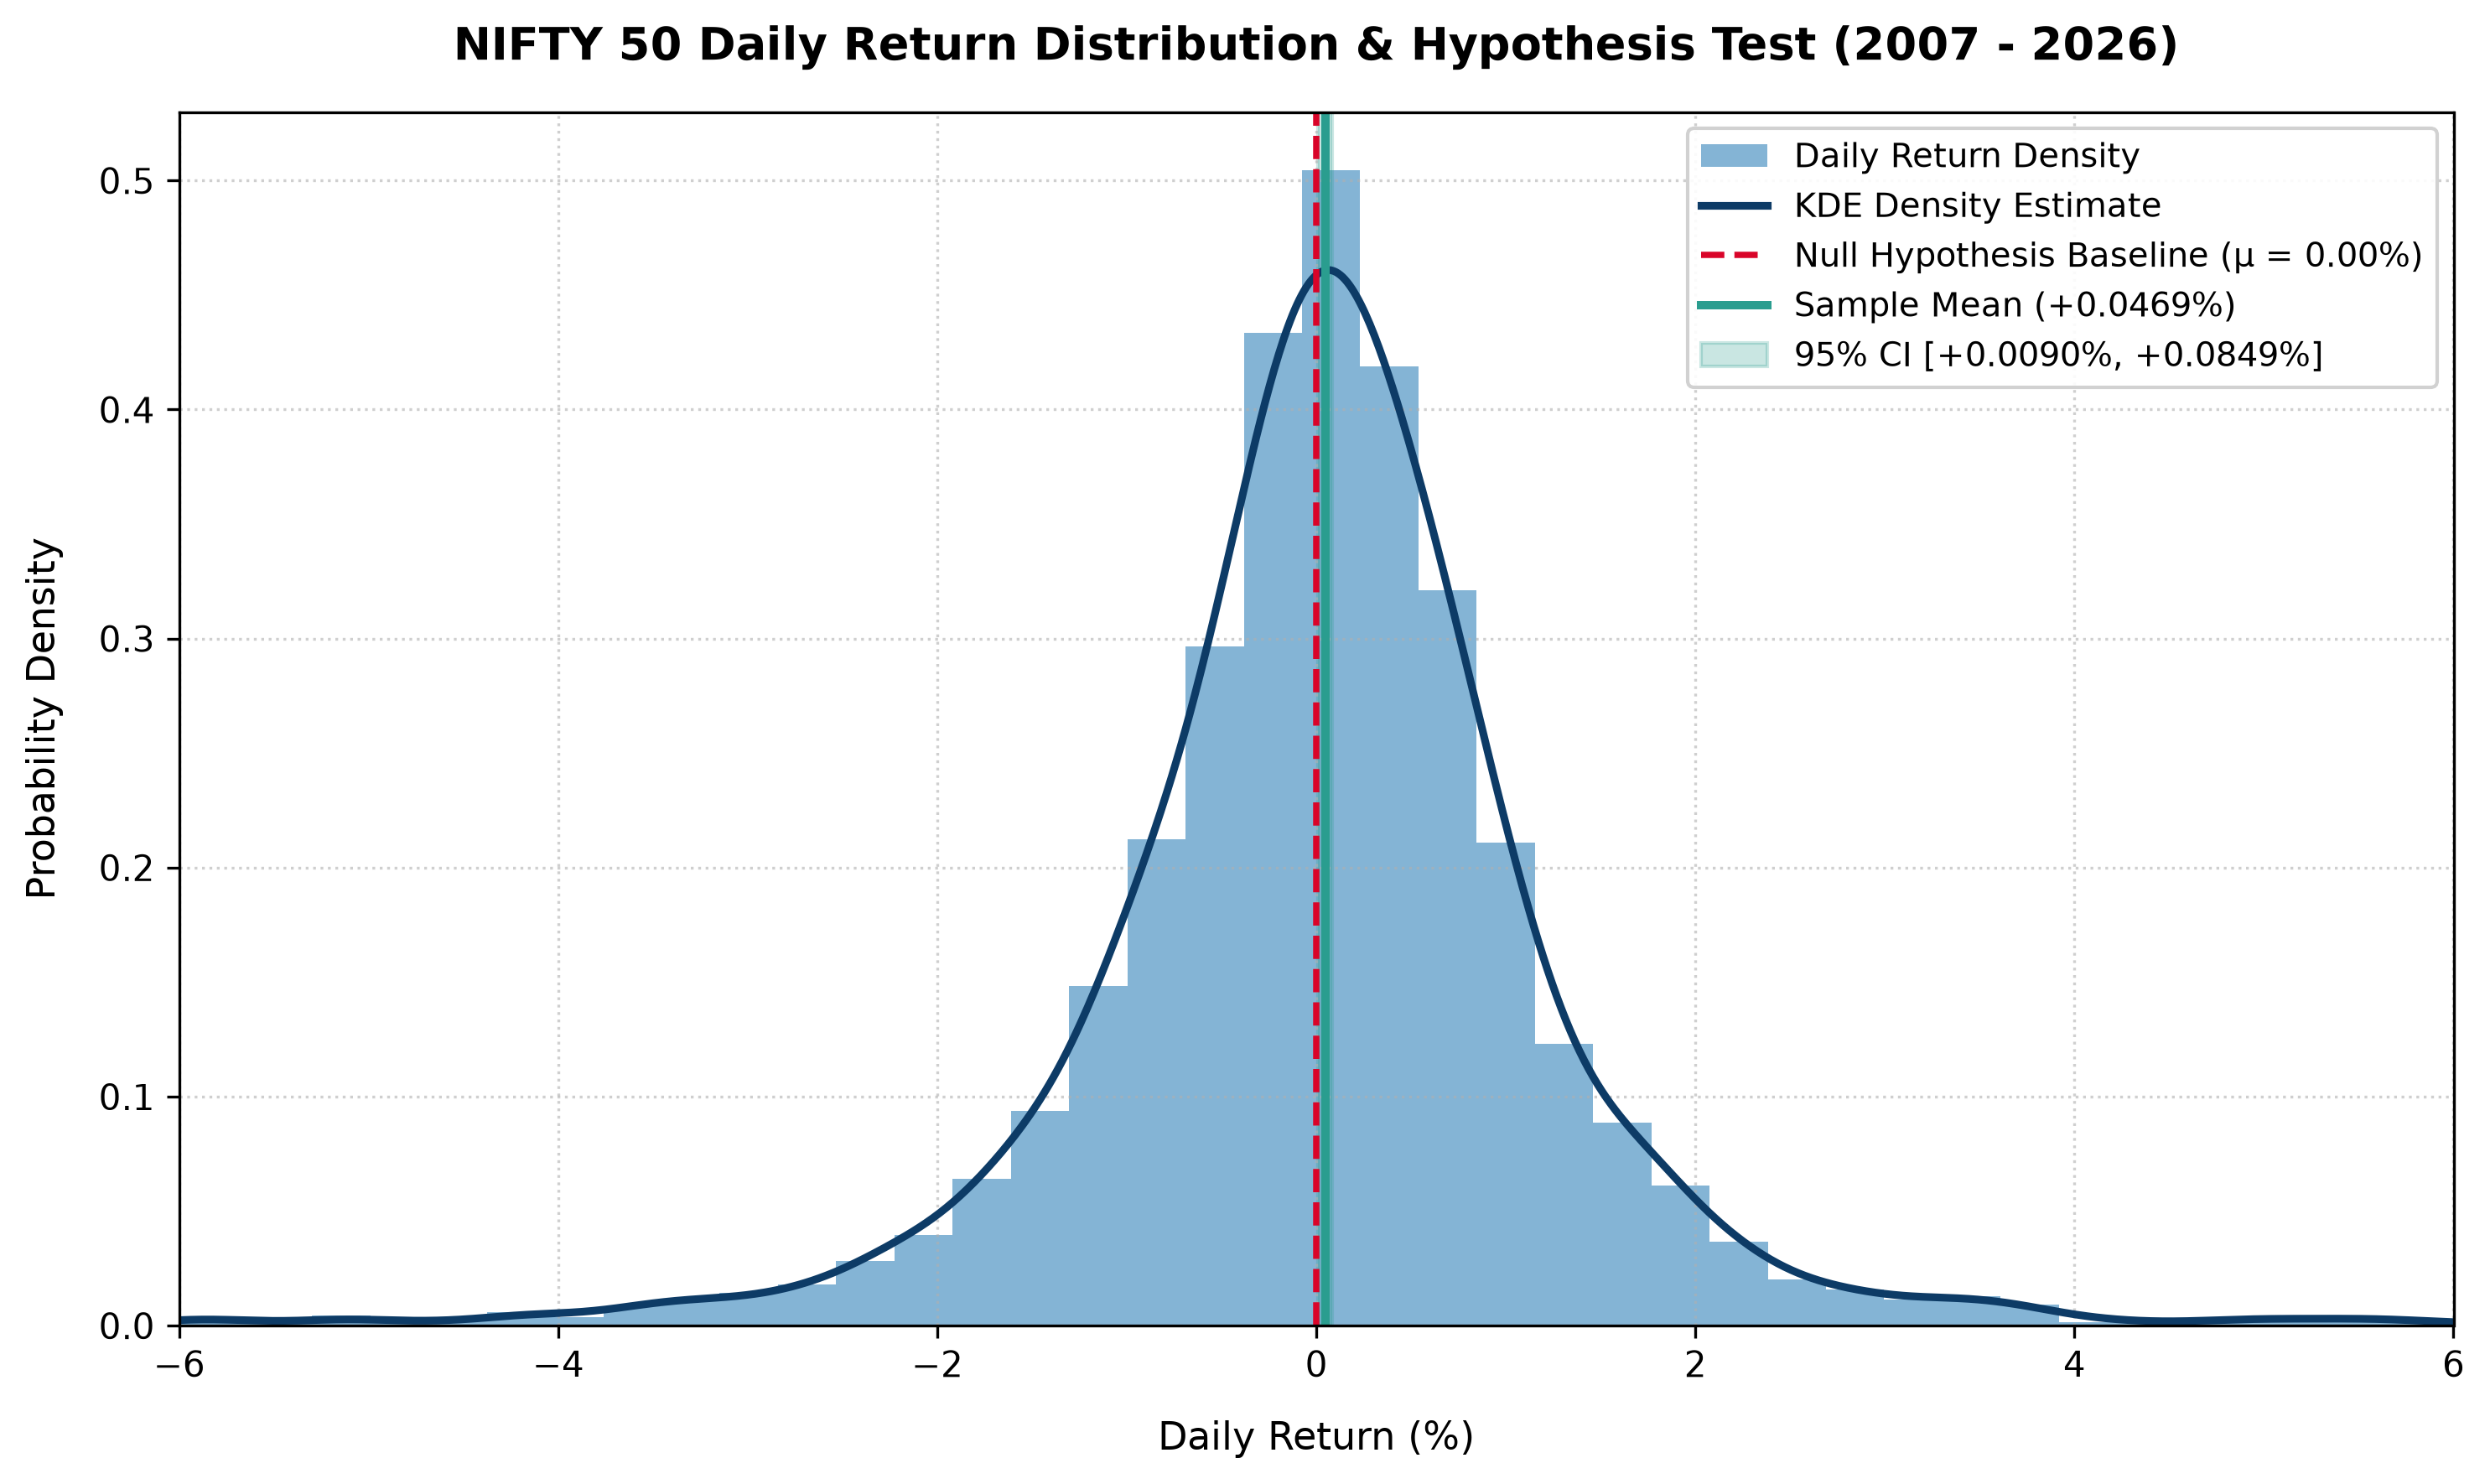

Saved asset: assets/week4_return_distribution.png


In [8]:
# Generate and save publication quality chart
plt.figure(figsize=(10, 6), dpi=300)

# Histogram
counts, bins, patches = plt.hist(clean_returns, bins=100, density=True, alpha=0.55, color='#1f77b4', label='Daily Return Density')

# KDE line
kde = stats.gaussian_kde(clean_returns)
x_axis = np.linspace(-6, 6, 1000)
plt.plot(x_axis, kde(x_axis), color='#0d3b66', linewidth=2.2, label='KDE Density Estimate')

# Reference Lines
plt.axvline(0, color='#d90429', linestyle='--', linewidth=1.8, label='Null Hypothesis Baseline (μ = 0.00%)')
plt.axvline(mean_val, color='#2a9d8f', linestyle='-', linewidth=2.4, label=f'Sample Mean ({mean_val:+.4f}%)')
plt.axvspan(ci_lower, ci_upper, color='#2a9d8f', alpha=0.25, label=f'95% CI [{ci_lower:+.4f}%, {ci_upper:+.4f}%]')

plt.xlim(-6, 6)
plt.title('NIFTY 50 Daily Return Distribution & Hypothesis Test (2007 - 2026)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Daily Return (%)', fontsize=11, labelpad=10)
plt.ylabel('Probability Density', fontsize=11, labelpad=10)
plt.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.9, fontsize=9.5)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

# Save chart asset
plt.savefig('assets/week4_return_distribution.png', bbox_inches='tight')
plt.show()
print("Saved asset: assets/week4_return_distribution.png")


## 13. Practical Meaning & Limitations

### Statistical vs. Economic Significance
* **Statistical Significance:** A daily mean return of **+0.0469%** is statistically distinguishable from zero due to the large sample size ($n = 4,521$).
* **Economic/Practical Significance:** A daily average return of +0.0469% translates to an annualized return of approximately **~12.5%** (compounded). However, on any single trading day, the daily standard deviation (**1.3015%**) is **27.7 times larger** than the daily mean return.
* **Predictability Warning:** Statistical significance does **NOT** imply market predictability or trade timing ability. The high signal-to-noise ratio means day-to-day fluctuations are dominated by volatility ("noise") rather than expected drift ("signal").

### Analysis Limitations
1. **Historical Period Dependency:** Analysis is bound to the 2007–2026 period, covering the 2008 GFC, 2020 COVID crash, and subsequent bull runs.
2. **Transaction Costs & Slippage:** Frictionless daily return compounding does not reflect real-world brokerage, taxes, or bid-ask spreads.
3. **Autocorrelation & Volatility Clustering:** ARCH/GARCH effects in financial data mean variance is not constant over time.


## 14. Conclusion

### Summary of Hypotheses & Results:
* **Research Question:** Is the average daily return of NIFTY 50 significantly different from zero?
* **Null Hypothesis ($H_0$):** $\mu = 0$
* **Alternative Hypothesis ($H_1$):** $\mu \neq 0$
* **Primary Test:** Two-Sided One-Sample t-Test
* **Sample Size ($n$):** 4,521 valid daily return observations
* **Sample Mean:** **+0.046935%** per day
* **t-Statistic:** **2.424855**
* **p-Value:** **0.015353**
* **Significance Level ($\alpha$):** 0.05
* **Final Statistical Decision:** **REJECT THE NULL HYPOTHESIS ($H_0$)**

### Final Takeaway:
The historical daily return of the NIFTY 50 index demonstrates a statistically significant positive mean drift over the 2007–2026 period, supporting long-term equity risk premium theory while emphasizing that daily volatility obscures directional predictability.
